# Credit Card Customer Segmentation Using K-Means Clustering

## Project Overview

This project analyzes credit card customer behavior and uses K-Means clustering to identify distinct customer segments based on account activity, credit usage, and transaction behavior.

The analysis explores customer characteristics, prepares and standardizes relevant features for clustering, evaluates multiple clustering solutions, and develops interpretable customer segments that can support more targeted customer strategies.

The final segments are also compared across characteristics that were not used to create the clusters, including income category, card category, and customer attrition.

## Business Problem

Credit card customers can have similar levels of transaction activity while using their available credit in very different ways. Understanding these differences can help financial institutions identify meaningful customer groups and develop more targeted engagement strategies.

The goal of this analysis is to identify distinct customer segments based on behavioral and financial characteristics and determine the key features that differentiate those segments.

## Objectives

- Explore and clean the customer dataset for analysis.
- Select relevant customer behavior and credit usage features for segmentation.
- Standardize numerical features for K-Means clustering.
- Evaluate different numbers of clusters using inertia and silhouette scores.
- Identify and interpret meaningful customer segments.
- Compare the final segments across credit usage, transaction behavior, income, card category, and attrition.
- Develop business insights and recommendations based on the identified customer segments.

## 1. Data Loading and Initial Exploration
The dataset contains customer demographic, account, credit usage, and transaction information. Before preparing the data for clustering, the dataset was reviewed to understand its structure, identify potential data quality issues, and determine which features would be relevant for customer segmentation.

### 1.1 Import libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

### 1.2 Load the dataset

In [2]:
customers_df = pd.read_csv("Credit_Card_Churn.csv")
customers_df.head()

,CLIENTNUM,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,...,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio
0,100000000,Existing Customer,57,F,0,Uneducated,Divorced,$40K - $60K,Blue,51,...,2,6,3206.56,1878.94,1327.62,1.07,13740,34,2.09,0.59
1,100000001,Attrited Customer,61,F,3,Post-Graduate,Single,$40K - $60K,Silver,19,...,2,6,5134.84,2498.54,2636.30,2.65,14279,64,0.61,0.49
2,100000002,Existing Customer,62,F,0,High School,Divorced,Less than $40K,Blue,31,...,6,3,20704.64,1581.42,19123.22,2.00,19353,41,1.36,0.08
3,100000003,Existing Customer,39,M,3,Doctorate,Married,$60K - $80K,Blue,20,...,0,5,28157.67,552.70,27604.97,2.56,18360,123,0.71,0.02
4,100000004,Existing Customer,52,F,3,Graduate,Single,$120K +,Blue,24,...,5,0,27955.43,1430.73,26524.70,0.60,1205,69,0.46,0.05


### 1.3 Examine the Dataset Structure

In [3]:
customers_df.shape

(10000, 21)

In [4]:
customers_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 21 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   CLIENTNUM                 10000 non-null  int64  
 1   Attrition_Flag            10000 non-null  str    
 2   Customer_Age              10000 non-null  int64  
 3   Gender                    10000 non-null  str    
 4   Dependent_count           10000 non-null  int64  
 5   Education_Level           10000 non-null  str    
 6   Marital_Status            10000 non-null  str    
 7   Income_Category           10000 non-null  str    
 8   Card_Category             10000 non-null  str    
 9   Months_on_book            10000 non-null  int64  
 10  Total_Relationship_Count  10000 non-null  int64  
 11  Months_Inactive_12_mon    10000 non-null  int64  
 12  Contacts_Count_12_mon     10000 non-null  int64  
 13  Credit_Limit              10000 non-null  float64
 14  Total_Revolving_Ba

### 1.4 Initial Data Quality Checks

The dataset was checked for missing values and duplicate customer records before feature selection and preprocessing.

In [5]:
customers_df.isnull().sum()

CLIENTNUM                   0
Attrition_Flag              0
Customer_Age                0
Gender                      0
Dependent_count             0
Education_Level             0
Marital_Status              0
Income_Category             0
Card_Category               0
Months_on_book              0
Total_Relationship_Count    0
Months_Inactive_12_mon      0
Contacts_Count_12_mon       0
Credit_Limit                0
Total_Revolving_Bal         0
Avg_Open_To_Buy             0
Total_Amt_Chng_Q4_Q1        0
Total_Trans_Amt             0
Total_Trans_Ct              0
Total_Ct_Chng_Q4_Q1         0
Avg_Utilization_Ratio       0
dtype: int64

In [6]:
customers_df.duplicated().sum()

np.int64(0)

### Summary Statistics

In [7]:
customers_df.describe()

,CLIENTNUM,Customer_Age,Dependent_count,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio
count,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,1.000050e+08,48.838600,2.520400,36.005700,3.506400,2.978300,3.026200,17968.595063,1237.206533,16731.388530,1.605785,10298.291200,79.628800,1.585808,0.133479
std,2.886896e+03,13.551609,1.699374,14.107167,1.718096,2.010332,2.001478,9897.031886,719.640899,9925.132928,0.808735,5644.752649,40.609136,0.805379,0.215122
min,1.000000e+08,26.000000,0.000000,12.000000,1.000000,0.000000,0.000000,1003.430000,0.070000,-1386.800000,0.200000,505.000000,10.000000,0.200000,0.000000
25%,1.000025e+08,37.000000,1.000000,24.000000,2.000000,1.000000,1.000000,9274.335000,610.682500,8062.305000,0.900000,5415.000000,44.000000,0.890000,0.030000
50%,1.000050e+08,49.000000,3.000000,36.000000,3.000000,3.000000,3.000000,18078.655000,1237.750000,16848.100000,1.610000,10244.000000,79.500000,1.580000,0.070000
75%,1.000075e+08,61.000000,4.000000,48.000000,5.000000,5.000000,5.000000,26632.392500,1853.325000,25380.857500,2.312500,15213.500000,115.000000,2.270000,0.130000
max,1.000100e+08,72.000000,5.000000,60.000000,6.000000,6.000000,6.000000,34999.730000,2499.940000,34974.310000,3.000000,19983.000000,149.000000,3.000000,2.330000


**Observation:** No missing values or duplicate records were identified, so no rows needed to be removed for these issues.

## 2. Data Validation

During the initial exploration, negative values were identified in `Avg_Open_To_Buy`. Because this variable represents the amount of credit available to a customer, these values were investigated before proceeding with the analysis.

### 2.1 Investigate negative open-to-buy values

In [8]:
negative_open_to_buy = customers_df[
    customers_df["Avg_Open_To_Buy"] < 0
]

negative_open_to_buy.shape[0]

153

A total of 153 customers had negative `Avg_Open_To_Buy` values, representing approximately 1.5% of the dataset. Rather than treating these values as errors automatically, the underlying calculation was validated using each customer's credit limit and revolving balance.

### 2.2 Validate the calculation

In [9]:
customers_df["Calculated_Open_To_Buy"] = (
    customers_df["Credit_Limit"] -
    customers_df["Total_Revolving_Bal"]
)

customers_df.loc[
    customers_df["Avg_Open_To_Buy"] < 0,
    [
        "Credit_Limit",
        "Total_Revolving_Bal",
        "Avg_Open_To_Buy",
        "Calculated_Open_To_Buy"
    ]
].head(10)

,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Calculated_Open_To_Buy
73,2236.46,2452.34,-215.88,-215.88
140,2338.37,2482.52,-144.15,-144.15
207,1819.75,2147.90,-328.15,-328.15
209,1322.28,1932.64,-610.36,-610.36
255,1263.89,1872.61,-608.72,-608.72
276,1308.20,2127.31,-819.11,-819.11
348,1044.36,2197.97,-1153.61,-1153.61
413,1698.91,1987.16,-288.25,-288.25
473,1581.85,2217.16,-635.31,-635.31
481,1157.42,1643.95,-486.53,-486.53


In [10]:
(
    customers_df["Avg_Open_To_Buy"].round(2) ==
    customers_df["Calculated_Open_To_Buy"].round(2)
).all()

np.True_

### 2.3 Document the conclusion

### Validation Result

The calculated open-to-buy values matched the values provided in the dataset. The negative values occurred when a customer's revolving balance exceeded their credit limit and were therefore retained rather than treated as data-entry errors.

No additional missing-value or duplicate-record cleaning was required.

In [11]:
customers_df.drop(
    columns="Calculated_Open_To_Buy",
    inplace=True
)

## 3. Feature Selection and Preprocessing

K-Means clustering groups observations based on similarity across the features provided to the model. Therefore, features were selected to focus the segmentation on customer relationship, credit usage, and transaction behavior while excluding identifiers, outcome variables, and redundant measures.

### 3.1 Feature selection

In [12]:
data_subset = customers_df[[
    "Customer_Age",
    "Income_Category",
    "Months_on_book",
    "Total_Relationship_Count",
    "Months_Inactive_12_mon",
    "Contacts_Count_12_mon",
    "Credit_Limit",
    "Total_Revolving_Bal",
    "Total_Amt_Chng_Q4_Q1",
    "Total_Trans_Amt",
    "Total_Trans_Ct",
    "Total_Ct_Chng_Q4_Q1",
    "Avg_Utilization_Ratio"
]].copy()

data_subset.head()

,Customer_Age,Income_Category,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio
0,57,$40K - $60K,51,1,2,6,3206.56,1878.94,1.07,13740,34,2.09,0.59
1,61,$40K - $60K,19,2,2,6,5134.84,2498.54,2.65,14279,64,0.61,0.49
2,62,Less than $40K,31,2,6,3,20704.64,1581.42,2.00,19353,41,1.36,0.08
3,39,$60K - $80K,20,5,0,5,28157.67,552.70,2.56,18360,123,0.71,0.02
4,52,$120K +,24,1,5,0,27955.43,1430.73,0.60,1205,69,0.46,0.05


Several variables were intentionally excluded from the initial clustering features:

- **CLIENTNUM:** Unique customer identifier with no behavioral meaning.
- **Attrition_Flag:** Excluded because attrition was treated as an outcome for post-clustering analysis rather than a feature used to create the segments.
- **Avg_Open_To_Buy:** Excluded because it is derived from Credit Limit and Total Revolving Balance, which were already included.
- **Gender, Dependent Count, Education Level, and Marital Status:** Retained for potential customer profiling rather than allowing demographic characteristics to drive the behavioral segmentation.
- **Card Category:** Retained for post-clustering profiling to determine whether card types differed across the resulting segments.

### 3.2 Categorical Feature Preparation

In [13]:
data_subset["Income_Category"].value_counts()

Income_Category
Unknown           1709
$120K +           1690
Less than $40K    1676
$60K - $80K       1659
$80K - $120K      1636
$40K - $60K       1630
Name: count, dtype: int64

Income Category was the only categorical feature included in the initial clustering feature set. Approximately 17% of customers had an `Unknown` income category. Because this represented a substantial portion of the dataset, these customers were retained rather than removed or assigned an assumed income level.

### 3.3 Encode Income Category

In [14]:
data_clean = data_subset.copy()

data_clean = pd.get_dummies(
    data_clean,
    columns=["Income_Category"],
    dtype="int"
)

data_clean.head()

,Customer_Age,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio,Income_Category_$120K +,Income_Category_$40K - $60K,Income_Category_$60K - $80K,Income_Category_$80K - $120K,Income_Category_Less than $40K,Income_Category_Unknown
0,57,51,1,2,6,3206.56,1878.94,1.07,13740,34,2.09,0.59,0,1,0,0,0,0
1,61,19,2,2,6,5134.84,2498.54,2.65,14279,64,0.61,0.49,0,1,0,0,0,0
2,62,31,2,6,3,20704.64,1581.42,2.00,19353,41,1.36,0.08,0,0,0,0,1,0
3,39,20,5,0,5,28157.67,552.70,2.56,18360,123,0.71,0.02,0,0,1,0,0,0
4,52,24,1,5,0,27955.43,1430.73,0.60,1205,69,0.46,0.05,1,0,0,0,0,0


One-hot encoding was used to convert Income Category into numerical features suitable for K-Means clustering. The `Unknown` category was retained as a separate indicator to avoid introducing assumed income information.

In [15]:
data_clean.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 18 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Customer_Age                    10000 non-null  int64  
 1   Months_on_book                  10000 non-null  int64  
 2   Total_Relationship_Count        10000 non-null  int64  
 3   Months_Inactive_12_mon          10000 non-null  int64  
 4   Contacts_Count_12_mon           10000 non-null  int64  
 5   Credit_Limit                    10000 non-null  float64
 6   Total_Revolving_Bal             10000 non-null  float64
 7   Total_Amt_Chng_Q4_Q1            10000 non-null  float64
 8   Total_Trans_Amt                 10000 non-null  int64  
 9   Total_Trans_Ct                  10000 non-null  int64  
 10  Total_Ct_Chng_Q4_Q1             10000 non-null  float64
 11  Avg_Utilization_Ratio           10000 non-null  float64
 12  Income_Category_$120K +         10000 non-nu

### 3.4 Feature Standardization

The selected features operate on very different numerical scales. For example, credit limits and transaction amounts are measured in thousands of dollars, while utilization ratios and inactivity measures have much smaller numerical ranges.

Because K-Means clustering is distance-based, features with larger numerical scales could otherwise have a disproportionate influence on cluster formation. StandardScaler was therefore applied so that each feature had approximately a mean of 0 and a standard deviation of 1.

In [16]:
scaler = StandardScaler()

df_scaled = pd.DataFrame(
    scaler.fit_transform(data_clean),
    columns=data_clean.columns
)

df_scaled.head()

,Customer_Age,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio,Income_Category_$120K +,Income_Category_$40K - $60K,Income_Category_$60K - $80K,Income_Category_$80K - $120K,Income_Category_Less than $40K,Income_Category_Unknown
0,0.602276,1.062938,-1.458897,-0.486660,1.485876,-1.491636,0.891786,-0.662531,0.609749,-1.123665,0.626062,2.122256,-0.450965,2.266047,-0.445979,-0.442267,-0.448715,-0.454012
1,0.897459,-1.205526,-0.876828,-0.486660,1.485876,-1.296793,1.752814,1.291235,0.705240,-0.384878,-1.211674,1.657380,-0.450965,2.266047,-0.445979,-0.442267,-0.448715,-0.454012
2,0.971254,-0.354852,-0.876828,1.503161,-0.013091,0.276465,0.478337,0.487471,1.604173,-0.951282,-0.280389,-0.248611,-0.450965,-0.441297,-0.445979,-0.442267,2.228584,-0.454012
3,-0.726046,-1.134636,0.869378,-1.481571,0.986221,1.029560,-0.951225,1.179945,1.428249,1.068069,-1.087503,-0.527537,-0.450965,-0.441297,2.242259,-0.442267,-0.448715,-0.454012
4,0.233298,-0.851078,-1.458897,1.005705,-1.512058,1.009124,0.268930,-1.243714,-1.611009,-0.261747,-1.397931,-0.388074,2.217467,-0.441297,-0.445979,-0.442267,-0.448715,-0.454012


In [17]:
df_scaled.describe().round(2)

,Customer_Age,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio,Income_Category_$120K +,Income_Category_$40K - $60K,Income_Category_$60K - $80K,Income_Category_$80K - $120K,Income_Category_Less than $40K,Income_Category_Unknown
count,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00
mean,0.00,0.00,-0.00,-0.00,0.00,-0.00,-0.00,-0.00,0.00,0.00,0.00,0.00,-0.00,-0.00,0.00,-0.00,-0.00,-0.00
std,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00
min,-1.69,-1.70,-1.46,-1.48,-1.51,-1.71,-1.72,-1.74,-1.74,-1.71,-1.72,-0.62,-0.45,-0.44,-0.45,-0.44,-0.45,-0.45
25%,-0.87,-0.85,-0.88,-0.98,-1.01,-0.88,-0.87,-0.87,-0.87,-0.88,-0.86,-0.48,-0.45,-0.44,-0.45,-0.44,-0.45,-0.45
50%,0.01,-0.00,-0.29,0.01,-0.01,0.01,0.00,0.01,-0.01,-0.00,-0.01,-0.30,-0.45,-0.44,-0.45,-0.44,-0.45,-0.45
75%,0.90,0.85,0.87,1.01,0.99,0.88,0.86,0.87,0.87,0.87,0.85,-0.02,-0.45,-0.44,-0.45,-0.44,-0.45,-0.45
max,1.71,1.70,1.45,1.50,1.49,1.72,1.75,1.72,1.72,1.71,1.76,10.21,2.22,2.27,2.24,2.26,2.23,2.20


## 4. K-Means Clustering: Initial Model

An initial K-Means clustering model was developed using the standardized feature set, including the one-hot encoded Income Category variables.

Because the appropriate number of customer segments was not known in advance, multiple values of `k` were evaluated using both inertia and silhouette scores.

### 4.1 Evaluate the number of clusters

In [18]:
inertia_values = []
silhouette_scores = []

for k in range(2, 16):
    kmeans = KMeans(
        n_clusters=k,
        n_init=10,
        random_state=42
    )

    kmeans.fit(df_scaled)

    inertia_values.append(kmeans.inertia_)
    silhouette_scores.append(
        silhouette_score(df_scaled, kmeans.labels_)
    )

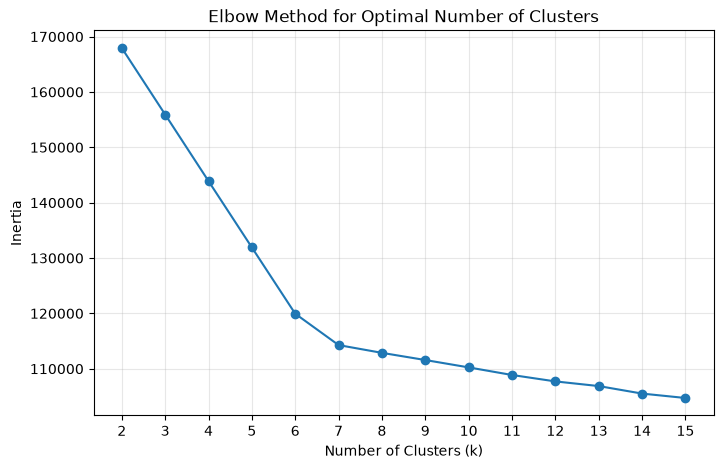

In [19]:
plt.figure(figsize=(8, 5))

plt.plot(
    range(2, 16),
    inertia_values,
    marker="o"
)

plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method for Optimal Number of Clusters")
plt.xticks(range(2, 16))
plt.grid(alpha=0.3)

plt.show()

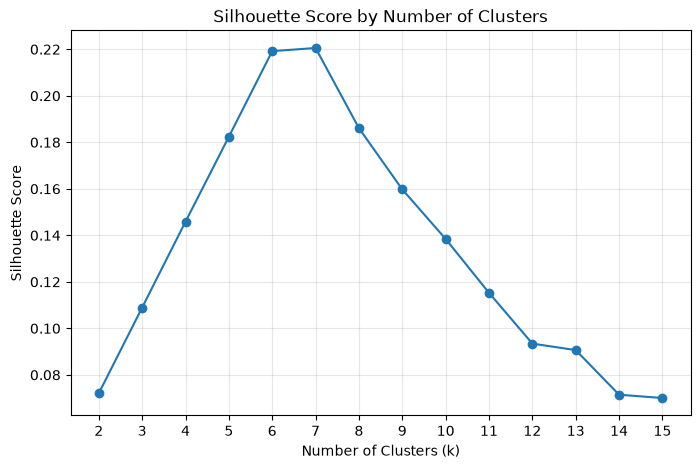

In [20]:
plt.figure(figsize=(8, 5))

plt.plot(
    range(2, 16),
    silhouette_scores,
    marker="o"
)

plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score by Number of Clusters")
plt.xticks(range(2, 16))
plt.grid(alpha=0.3)

plt.show()

The elbow curve began to flatten around 6–7 clusters, while the silhouette score reached its highest value at 7 clusters. Based on these initial results, a seven-cluster solution was selected for further examination.

### 4.2 Initial Seven-Cluster Model

In [21]:
kmeans7 = KMeans(
    n_clusters=7,
    n_init=10,
    random_state=42
)

kmeans7.fit(df_scaled)

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",7
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",10
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary <random_state>`.",42
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'
Name,Type,Value
"cluster_centers_ cluster_centers_: ndarray of shape (n_clusters, n_features)Coordinates of cluster centers. If the algorithm stops before fullyconverging (see ``tol`` and ``max_iter``), these will not beconsistent with ``labels_``.","ndarray[float64](7, 18)","[[ 0

In [22]:
cluster_counts = (
    pd.Series(kmeans7.labels_)
    .value_counts()
    .sort_index()
)

cluster_counts

0    1566
1     347
2    1573
3    1640
4    1649
5    1621
6    1604
Name: count, dtype: int64

Most clusters contained approximately 1,500–1,650 customers, while Cluster 1 was substantially smaller with 347 customers. The cluster characteristics were therefore examined to understand what was driving this separation.

### 4.3 Examine the Cluster Centers

In [23]:
cluster_centers = pd.DataFrame(
    kmeans7.cluster_centers_,
    columns=df_scaled.columns
)

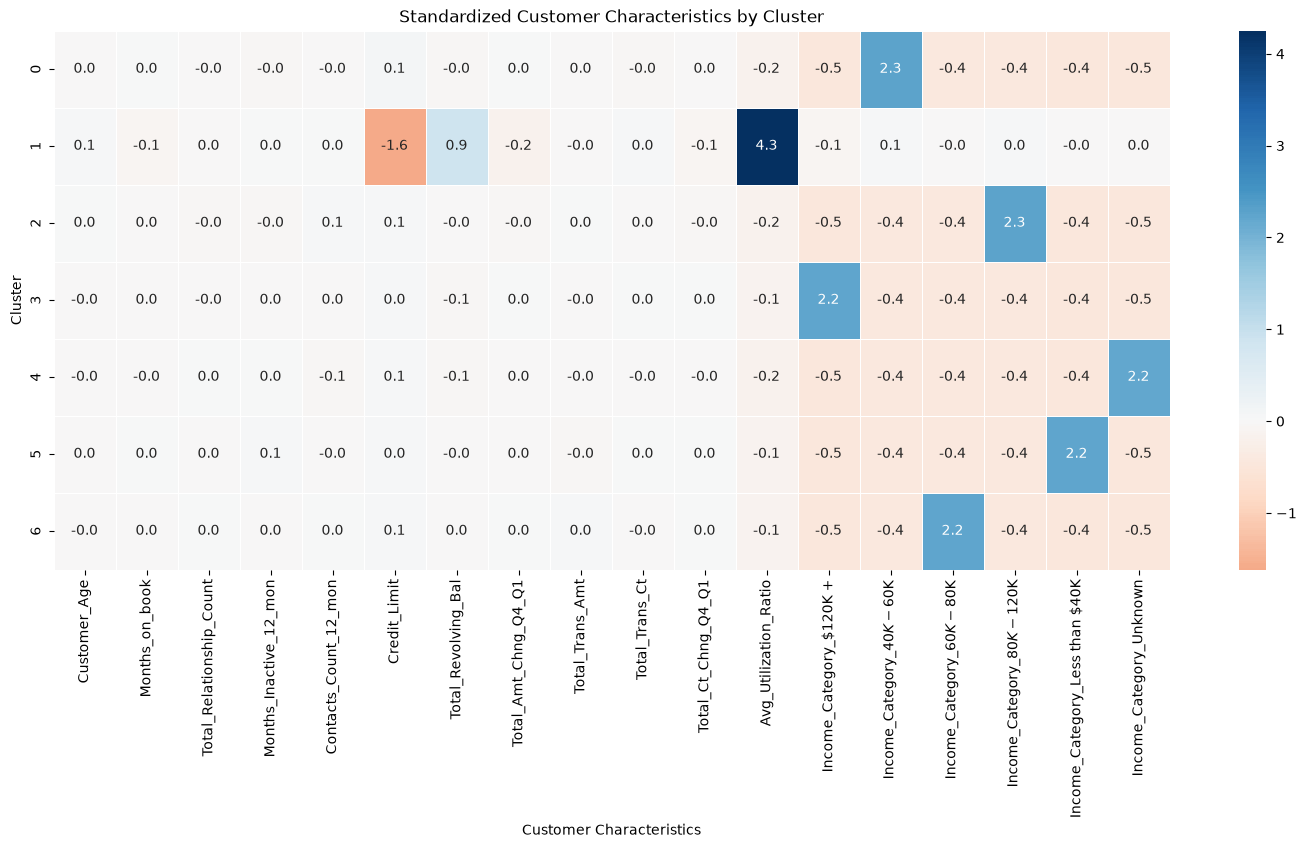

In [24]:
plt.figure(figsize=(18, 7))

sns.heatmap(
    cluster_centers,
    annot=True,
    cmap="RdBu",
    center=0,
    fmt=".1f",
    linewidths=0.5
)

plt.title("Standardized Customer Characteristics by Cluster")
plt.xlabel("Customer Characteristics")
plt.ylabel("Cluster")

plt.show()

The cluster-center heatmap revealed that the initial segments were driven primarily by the one-hot encoded Income Category variables rather than broader differences in customer behavior.

Six of the seven clusters were strongly associated with individual income categories, while most behavioral features remained close to the overall mean.

This indicated that Income Category was disproportionately influencing the distance calculations used by K-Means and limiting the usefulness of the resulting customer segments.

### 4.4 Evaluating the Influence of Income Category

Before removing Income Category from the clustering model, average customer characteristics were compared across income groups to determine whether the categories represented substantial differences in customer behavior.

In [25]:
income_summary = customers_df.groupby("Income_Category")[
    [
        "Customer_Age",
        "Months_on_book",
        "Total_Relationship_Count",
        "Months_Inactive_12_mon",
        "Contacts_Count_12_mon",
        "Credit_Limit",
        "Total_Revolving_Bal",
        "Total_Amt_Chng_Q4_Q1",
        "Total_Trans_Amt",
        "Total_Trans_Ct",
        "Total_Ct_Chng_Q4_Q1",
        "Avg_Utilization_Ratio"
    ]
].mean().round(2)

income_summary

,Customer_Age,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio
Income_Category,,,,,,,,,,,,
$120K +,48.82,35.93,3.50,2.99,3.03,17834.16,1218.17,1.61,10253.79,80.41,1.60,0.13
$40K - $60K,49.03,36.08,3.51,2.91,2.96,18204.47,1230.10,1.62,10277.28,77.67,1.58,0.13
$60K - $80K,48.78,35.94,3.54,3.00,3.08,17998.44,1256.87,1.62,10495.32,79.61,1.59,0.13
$80K - $120K,49.14,36.15,3.43,2.89,3.17,17975.91,1254.06,1.57,10411.31,79.93,1.56,0.14
Less than $40K,48.81,36.27,3.52,3.07,3.00,17900.58,1239.83,1.61,10114.39,80.60,1.60,0.13
Unknown,48.48,35.67,3.54,3.00,2.92,17907.30,1225.01,1.60,10243.23,79.51,1.58,0.13


Customers across the income categories showed relatively similar average characteristics, including age, relationship length, transaction activity, revolving balance, and credit utilization.

Because Income Category strongly influenced the initial cluster assignments without corresponding to substantial differences across most behavioral measures, it was removed from the clustering feature set for the refined model.

## 5. Refined Clustering Model

The initial model showed that Income Category disproportionately influenced cluster formation. To focus the segmentation on customer financial and behavioral characteristics, Income Category was removed from the clustering feature set.

The revised features were then standardized and the clustering process was repeated to determine whether more meaningful behavioral customer segments could be identified.

### 5.1 Revised Feature Set

In [26]:
data_clean2 = data_subset.drop(
    columns=["Income_Category"]
).copy()

data_clean2.head()

,Customer_Age,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio
0,57,51,1,2,6,3206.56,1878.94,1.07,13740,34,2.09,0.59
1,61,19,2,2,6,5134.84,2498.54,2.65,14279,64,0.61,0.49
2,62,31,2,6,3,20704.64,1581.42,2.00,19353,41,1.36,0.08
3,39,20,5,0,5,28157.67,552.70,2.56,18360,123,0.71,0.02
4,52,24,1,5,0,27955.43,1430.73,0.60,1205,69,0.46,0.05


In [27]:
data_clean2.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Customer_Age              10000 non-null  int64  
 1   Months_on_book            10000 non-null  int64  
 2   Total_Relationship_Count  10000 non-null  int64  
 3   Months_Inactive_12_mon    10000 non-null  int64  
 4   Contacts_Count_12_mon     10000 non-null  int64  
 5   Credit_Limit              10000 non-null  float64
 6   Total_Revolving_Bal       10000 non-null  float64
 7   Total_Amt_Chng_Q4_Q1      10000 non-null  float64
 8   Total_Trans_Amt           10000 non-null  int64  
 9   Total_Trans_Ct            10000 non-null  int64  
 10  Total_Ct_Chng_Q4_Q1       10000 non-null  float64
 11  Avg_Utilization_Ratio     10000 non-null  float64
dtypes: float64(5), int64(7)
memory usage: 937.6 KB


In [28]:
scaler2 = StandardScaler()

df_scaled2 = pd.DataFrame(
    scaler2.fit_transform(data_clean2),
    columns=data_clean2.columns
)

df_scaled2.describe().round(2)

,Customer_Age,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio
count,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00
mean,0.00,0.00,-0.00,-0.00,0.00,-0.00,-0.00,-0.00,0.00,0.00,0.00,0.00
std,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00
min,-1.69,-1.70,-1.46,-1.48,-1.51,-1.71,-1.72,-1.74,-1.74,-1.71,-1.72,-0.62
25%,-0.87,-0.85,-0.88,-0.98,-1.01,-0.88,-0.87,-0.87,-0.87,-0.88,-0.86,-0.48
50%,0.01,-0.00,-0.29,0.01,-0.01,0.01,0.00,0.01,-0.01,-0.00,-0.01,-0.30
75%,0.90,0.85,0.87,1.01,0.99,0.88,0.86,0.87,0.87,0.87,0.85,-0.02
max,1.71,1.70,1.45,1.50,1.49,1.72,1.75,1.72,1.72,1.71,1.76,10.21


The revised feature set contained 12 numerical customer characteristics. These features were standardized again so that each variable contributed comparably to the distance calculations used by K-Means.

### 5.2 Re-evaluating the Number of Clusters

Because removing Income Category changed the feature space used by the model, the optimal number of clusters was evaluated again rather than assuming that the previous seven-cluster solution would remain appropriate.

In [29]:
inertia_values2 = []
silhouette_scores2 = []

for k in range(2, 16):
    kmeans = KMeans(
        n_clusters=k,
        n_init=10,
        random_state=42
    )
    
    kmeans.fit(df_scaled2)
    
    inertia_values2.append(kmeans.inertia_)
    silhouette_scores2.append(
        silhouette_score(df_scaled2, kmeans.labels_)
    )

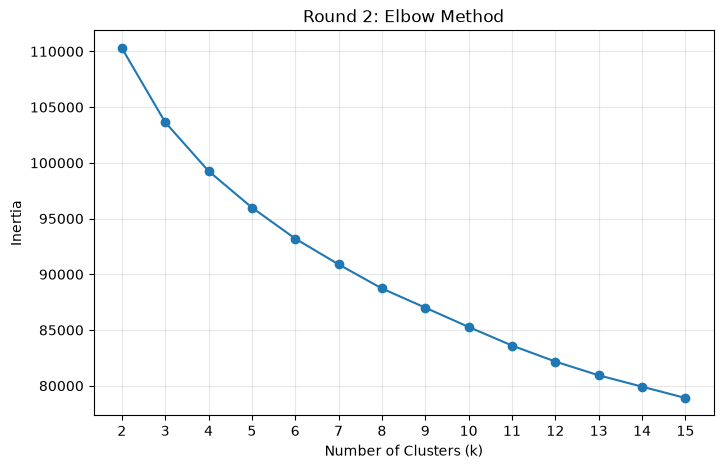

In [30]:
plt.figure(figsize=(8, 5))

plt.plot(
    range(2, 16),
    inertia_values2,
    marker="o"
)

plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.title("Round 2: Elbow Method")
plt.xticks(range(2, 16))
plt.grid(alpha=0.3)

plt.show()

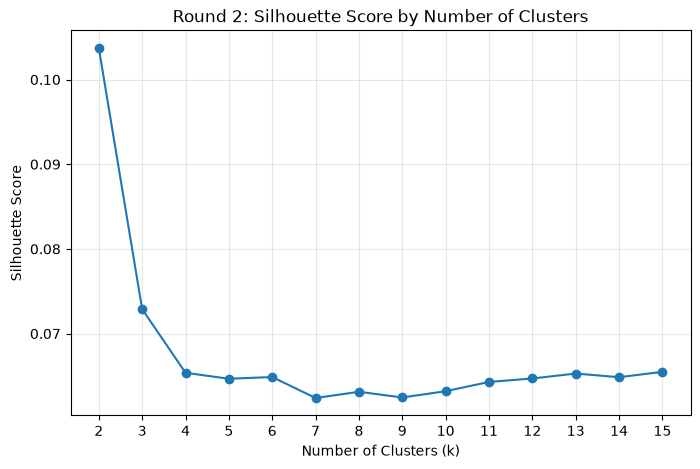

In [31]:
plt.figure(figsize=(8, 5))

plt.plot(
    range(2, 16),
    silhouette_scores2,
    marker="o"
)

plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("Round 2: Silhouette Score by Number of Clusters")
plt.xticks(range(2, 16))
plt.grid(alpha=0.3)

plt.show()

Unlike the initial model, the revised elbow curve did not show a strong, clearly defined elbow. The silhouette scores also indicated relatively weak separation between the potential customer groups.

The two-cluster solution achieved the highest silhouette score, but additional solutions were examined to determine whether a slightly more complex model could provide more useful and interpretable customer segments.

### 5.3 Comparing Candidate Cluster Solutions

Two-, three-, and four-cluster solutions were compared based on statistical performance, cluster size, and interpretability.

In [32]:
for k in [2, 3, 4]:
    print(
        f"k={k}: "
        f"Inertia={inertia_values2[k-2]:.2f}, "
        f"Silhouette={silhouette_scores2[k-2]:.3f}"
    )

kmeans2 = KMeans(n_clusters=2, n_init=10, random_state=42)
kmeans3 = KMeans(n_clusters=3, n_init=10, random_state=42)
kmeans4 = KMeans(n_clusters=4, n_init=10, random_state=42)

kmeans2.fit(df_scaled2)
kmeans3.fit(df_scaled2)
kmeans4.fit(df_scaled2)

for name, model in [
    ("k=2", kmeans2),
    ("k=3", kmeans3),
    ("k=4", kmeans4)
]:
    print(name)
    print(pd.Series(model.labels_).value_counts().sort_index())
    print()

k=2: Inertia=110306.15, Silhouette=0.104
k=3: Inertia=103648.04, Silhouette=0.073
k=4: Inertia=99268.99, Silhouette=0.065
k=2
0    2501
1    7499
Name: count, dtype: int64

k=3
0    4565
1    1366
2    4069
Name: count, dtype: int64

k=4
0    2882
1    1059
2    2919
3    3140
Name: count, dtype: int64



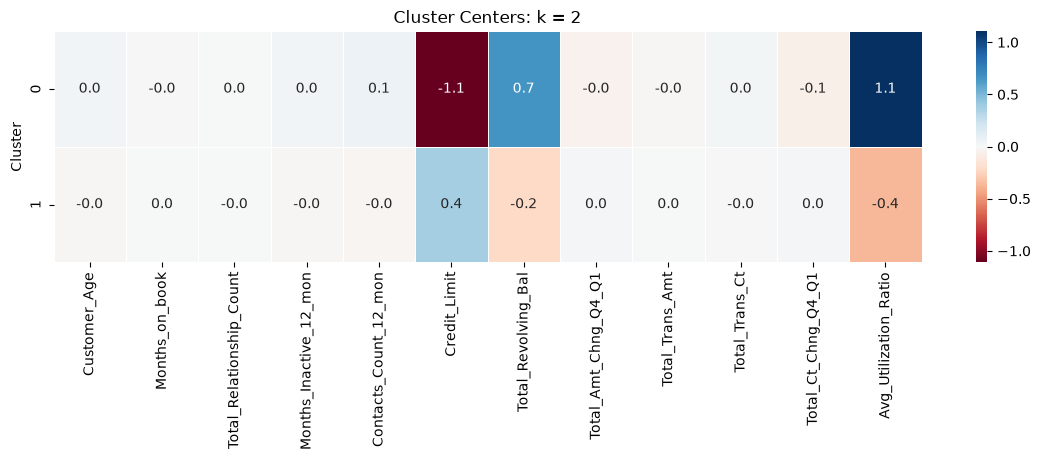

In [33]:
centers2 = pd.DataFrame(
    kmeans2.cluster_centers_,
    columns=df_scaled2.columns
)

plt.figure(figsize=(14, 3))

sns.heatmap(
    centers2,
    annot=True,
    cmap="RdBu",
    center=0,
    fmt=".1f",
    linewidths=0.5
)

plt.title("Cluster Centers: k = 2")
plt.ylabel("Cluster")
plt.show()

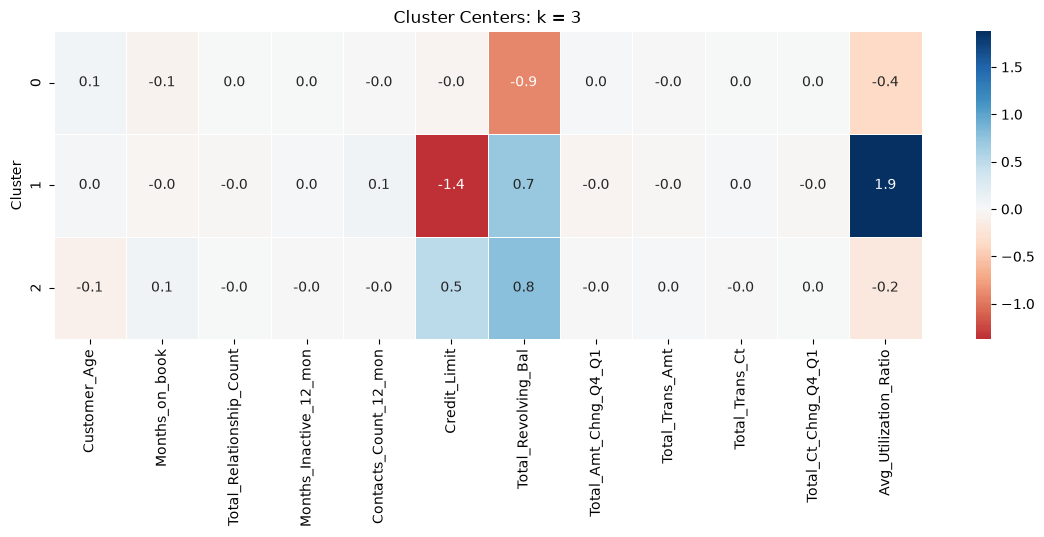

In [34]:
centers3 = pd.DataFrame(
    kmeans3.cluster_centers_,
    columns=df_scaled2.columns
)

plt.figure(figsize=(14, 4))

sns.heatmap(
    centers3,
    annot=True,
    cmap="RdBu",
    center=0,
    fmt=".1f",
    linewidths=0.5
)

plt.title("Cluster Centers: k = 3")
plt.ylabel("Cluster")
plt.show()

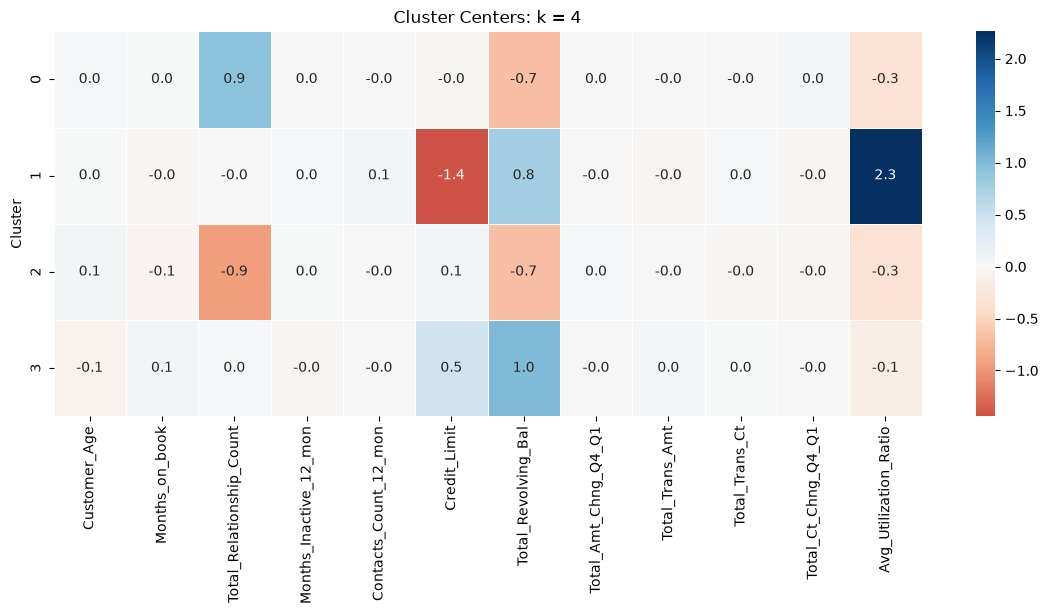

In [35]:
centers4 = pd.DataFrame(
    kmeans4.cluster_centers_,
    columns=df_scaled2.columns
)

plt.figure(figsize=(14, 5))

sns.heatmap(
    centers4,
    annot=True,
    cmap="RdBu",
    center=0,
    fmt=".1f",
    linewidths=0.5
)

plt.title("Cluster Centers: k = 4")
plt.ylabel("Cluster")
plt.show()

### 5.4 Final Model Selection

Although the two-cluster solution achieved the highest silhouette score, it primarily produced a broad separation between customers with higher and lower credit utilization.

The three-cluster solution revealed an additional distinct credit behavior profile while remaining relatively simple and interpretable. Increasing the model to four clusters further reduced the silhouette score and provided limited additional behavioral separation.

Therefore, three clusters were selected for the final segmentation as a balance between statistical performance and business interpretability.

The relatively low silhouette scores indicate that the customer groups are not strongly separated, which is considered a limitation of the segmentation.

In [36]:
pd.Series(kmeans3.labels_).value_counts().sort_index()

0    4565
1    1366
2    4069
Name: count, dtype: int64

## 6. Customer Segment Profiling

After selecting the three-cluster solution, the cluster labels were assigned to the original unscaled customer data. This allows the segments to be interpreted using actual values such as credit limits, revolving balances, transaction activity, and credit utilization.

### 6.1 Assigning Cluster Labels

In [37]:
customer_segments = customers_df.copy()

customer_segments["Cluster"] = kmeans3.labels_

customer_segments.head()

,CLIENTNUM,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,...,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio,Cluster
0,100000000,Existing Customer,57,F,0,Uneducated,Divorced,$40K - $60K,Blue,51,...,6,3206.56,1878.94,1327.62,1.07,13740,34,2.09,0.59,1
1,100000001,Attrited Customer,61,F,3,Post-Graduate,Single,$40K - $60K,Silver,19,...,6,5134.84,2498.54,2636.30,2.65,14279,64,0.61,0.49,1
2,100000002,Existing Customer,62,F,0,High School,Divorced,Less than $40K,Blue,31,...,3,20704.64,1581.42,19123.22,2.00,19353,41,1.36,0.08,2
3,100000003,Existing Customer,39,M,3,Doctorate,Married,$60K - $80K,Blue,20,...,5,28157.67,552.70,27604.97,2.56,18360,123,0.71,0.02,0
4,100000004,Existing Customer,52,F,3,Graduate,Single,$120K +,Blue,24,...,0,27955.43,1430.73,26524.70,0.60,1205,69,0.46,0.05,2


In [38]:
customer_segments["Cluster"].value_counts().sort_index()

Cluster
0    4565
1    1366
2    4069
Name: count, dtype: int64

### 6.2 Customer Characteristics by Cluster

Average customer characteristics were calculated using the original unscaled values to identify the financial and behavioral features that distinguish each cluster.

In [39]:
cluster_profile = customer_segments.groupby("Cluster")[
    [
        "Customer_Age",
        "Months_on_book",
        "Total_Relationship_Count",
        "Months_Inactive_12_mon",
        "Contacts_Count_12_mon",
        "Credit_Limit",
        "Total_Revolving_Bal",
        "Avg_Open_To_Buy",
        "Total_Amt_Chng_Q4_Q1",
        "Total_Trans_Amt",
        "Total_Trans_Ct",
        "Total_Ct_Chng_Q4_Q1",
        "Avg_Utilization_Ratio"
    ]
].mean().round(2)

cluster_profile.T

Cluster,0,1,2
Customer_Age,49.80,49.38,47.58
Months_on_book,35.09,35.55,37.18
Total_Relationship_Count,3.52,3.46,3.51
Months_Inactive_12_mon,2.99,3.04,2.95
Contacts_Count_12_mon,3.00,3.20,2.99
Credit_Limit,17554.27,4354.33,23003.86
Total_Revolving_Bal,584.38,1752.50,1796.63
Avg_Open_To_Buy,16969.89,2601.83,21207.23
Total_Amt_Chng_Q4_Q1,1.62,1.57,1.60
Total_Trans_Amt,10220.22,10149.84,10435.72


### 6.3 Segment Interpretation

Most customer characteristics, including age, relationship length, transaction activity, inactivity, and contact frequency, were relatively similar across the three clusters.

The strongest differences were observed in credit limit, revolving balance, available credit, and credit utilization.

**Cluster 0 – Low Utilization Customers**
- Average credit limit of approximately $17,554.
- Low average revolving balance of approximately $584.
- Average credit utilization of approximately 5%.
- Transaction activity remained comparable to the other customer groups.

These customers have moderate credit capacity but carry relatively little revolving credit.

**Cluster 1 – High Utilization Customers**
- Lowest average credit limit at approximately $4,354.
- Average revolving balance of approximately $1,753.
- Highest average credit utilization at approximately 54%.
- Average available credit of approximately $2,602.

These customers use a substantially larger proportion of their available credit than the other segments.

**Cluster 2 – High Credit Capacity Customers**
- Highest average credit limit at approximately $23,004.
- Average revolving balance of approximately $1,797.
- Average available credit of approximately $21,207.
- Relatively low average credit utilization of approximately 9%.

These customers carry revolving balances similar to the High Utilization segment but have substantially greater available credit, resulting in much lower utilization.

### 6.4 Assigning Segment Names

Descriptive names were assigned to each cluster based on the characteristics that most clearly differentiated the customer groups.

In [40]:
cluster_names = {
    0: "Low Utilization",
    1: "High Utilization",
    2: "High Credit Capacity"
}

customer_segments["Segment"] = (
    customer_segments["Cluster"].map(cluster_names)
)

customer_segments[
    ["Cluster", "Segment", "Credit_Limit",
     "Total_Revolving_Bal", "Avg_Utilization_Ratio"]
].head()

,Cluster,Segment,Credit_Limit,Total_Revolving_Bal,Avg_Utilization_Ratio
0,1,High Utilization,3206.56,1878.94,0.59
1,1,High Utilization,5134.84,2498.54,0.49
2,2,High Credit Capacity,20704.64,1581.42,0.08
3,0,Low Utilization,28157.67,552.70,0.02
4,2,High Credit Capacity,27955.43,1430.73,0.05


## 7. Post-Clustering Analysis

After defining the final customer segments, additional characteristics that were not used to create the clusters were examined. This helps determine whether the behavioral segments are associated with differences in customer attrition, income category, or card category.

### 7.1 Attrition by Customer Segment

In [41]:
customer_segments["Attrited"] = (
    customer_segments["Attrition_Flag"] == "Attrited Customer"
).astype(int)

attrition_by_segment = (
    customer_segments
    .groupby("Segment")["Attrited"]
    .agg(["count", "sum", "mean"])
)

attrition_by_segment["mean"] = (
    attrition_by_segment["mean"] * 100
).round(2)

attrition_by_segment = attrition_by_segment.rename(
    columns={
        "count": "Customers",
        "sum": "Attrited_Customers",
        "mean": "Attrition_Rate"
    }
)

attrition_by_segment

,Customers,Attrited_Customers,Attrition_Rate
Segment,,,
High Credit Capacity,4069,648,15.93
High Utilization,1366,193,14.13
Low Utilization,4565,697,15.27


Attrition rates were relatively similar across the three customer segments, ranging from approximately 14% to 16%.

The High Utilization segment had the lowest attrition rate, while the High Credit Capacity segment had the highest. However, the differences were small.

This suggests that the credit usage characteristics defining the customer segments are not strongly associated with differences in attrition. The segments are therefore more useful for understanding customer credit behavior than for identifying customers at risk of attrition.

### 7.2 Income Distribution by Customer Segment

In [42]:
income_by_segment = pd.crosstab(
    customer_segments["Segment"],
    customer_segments["Income_Category"],
    normalize="index"
) * 100

income_by_segment.round(1)

Income_Category,$120K +,$40K - $60K,$60K - $80K,$80K - $120K,Less than $40K,Unknown
Segment,,,,,,
High Credit Capacity,16.5,16.1,17.2,17.1,16.6,16.4
High Utilization,16.8,15.4,16.3,16.3,17.6,17.6
Low Utilization,17.3,16.7,16.2,15.7,16.6,17.5


Income categories were relatively evenly distributed across the three customer segments, with only small differences between groups.

This further supports the decision to exclude Income Category from the refined clustering model, as income did not meaningfully distinguish the final behavioral segments.

### 7.3 Card Category Distribution by Customer Segment

In [43]:
card_by_segment = pd.crosstab(
    customer_segments["Segment"],
    customer_segments["Card_Category"],
    normalize="index"
) * 100

card_by_segment.round(1)

Card_Category,Blue,Gold,Platinum,Silver
Segment,,,,
High Credit Capacity,92.7,2.2,1.9,3.2
High Utilization,92.8,2.0,2.6,2.6
Low Utilization,93.4,2.2,1.6,2.8


Card category distributions were also similar across the three customer segments. Blue cards represented approximately 93% of customers in each segment, while Gold, Platinum, and Silver cards represented much smaller shares.

Card Category therefore did not meaningfully distinguish the final customer segments.

## 8. Final Visualizations and Key Insights

The final customer segments were visualized using the characteristics that most clearly differentiated the groups. These visualizations summarize segment size, credit capacity, revolving balances, and credit utilization.

### 8.1 Customer Distribution by Segment

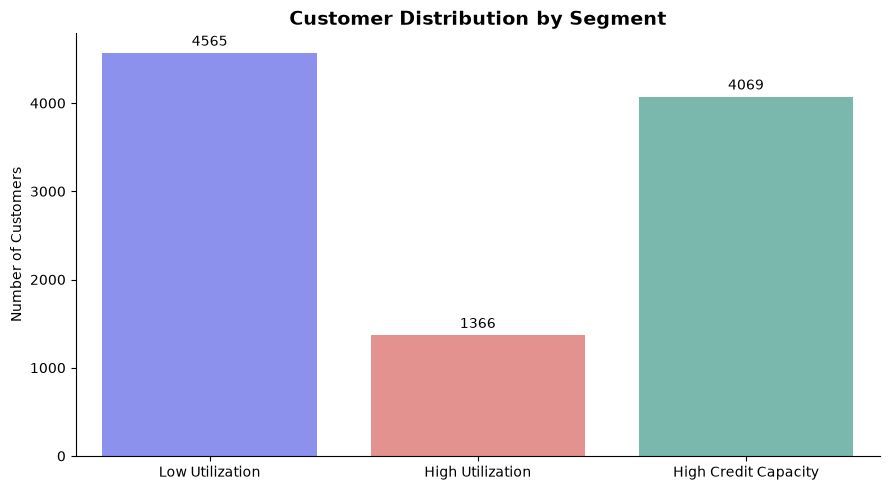

In [44]:
segment_counts = (
    customer_segments["Segment"]
    .value_counts()
    .reindex([
        "Low Utilization",
        "High Utilization",
        "High Credit Capacity"
    ])
)

plt.figure(figsize=(9, 5))

ax = sns.barplot(
    x=segment_counts.index,
    y=segment_counts.values,
    hue=segment_counts.index,
    palette=["#7C83FD", "#F28482", "#70C1B3"],
    legend=False
)

plt.title("Customer Distribution by Segment", fontsize=14, fontweight="bold")
plt.xlabel("")
plt.ylabel("Number of Customers")

for container in ax.containers:
    ax.bar_label(container, fmt="%d", padding=3)

sns.despine()
plt.tight_layout()
plt.show()

**Key Insight:** Low Utilization customers represent the largest segment, followed closely by High Credit Capacity customers. High Utilization customers form the smallest segment, accounting for approximately 14% of the customer base.

### 8.2 Credit Capacity and Revolving Balance by Segment

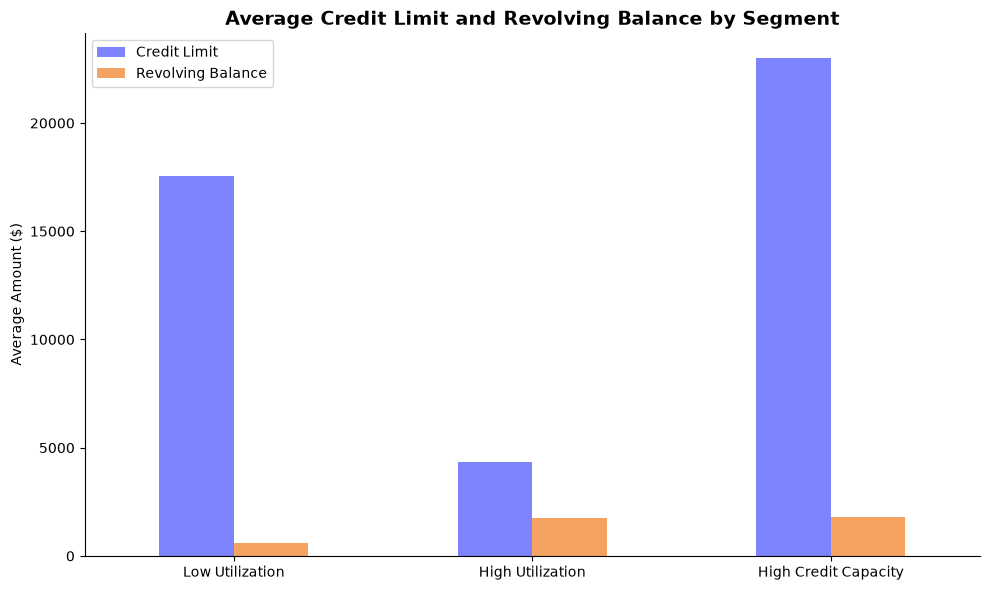

In [45]:
credit_comparison = (
    customer_segments
    .groupby("Segment")[["Credit_Limit", "Total_Revolving_Bal"]]
    .mean()
    .reindex([
        "Low Utilization",
        "High Utilization",
        "High Credit Capacity"
    ])
)

credit_comparison.plot(
    kind="bar",
    figsize=(10, 6),
    color=["#7C83FD", "#F4A261"]
)

plt.title(
    "Average Credit Limit and Revolving Balance by Segment",
    fontsize=14,
    fontweight="bold"
)
plt.xlabel("")
plt.ylabel("Average Amount ($)")
plt.xticks(rotation=0)
plt.legend(["Credit Limit", "Revolving Balance"])

sns.despine()
plt.tight_layout()
plt.show()

**Key Insight:** High Credit Capacity customers have the highest average credit limits, while High Utilization customers have substantially lower credit limits despite carrying revolving balances similar to High Credit Capacity customers. Low Utilization customers carry considerably smaller revolving balances relative to their available credit.

### 8.3 Credit Utilization by Segment

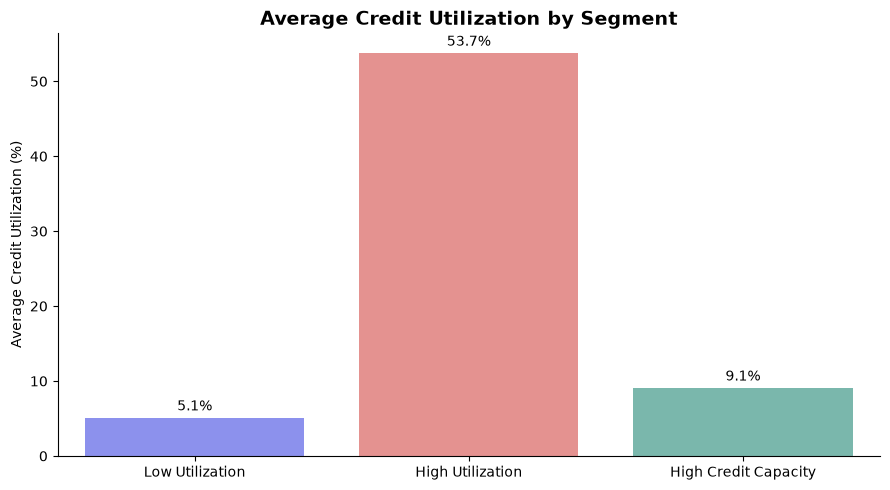

In [46]:
utilization = (
    customer_segments
    .groupby("Segment")["Avg_Utilization_Ratio"]
    .mean()
    .mul(100)
    .reindex([
        "Low Utilization",
        "High Utilization",
        "High Credit Capacity"
    ])
)

plt.figure(figsize=(9, 5))

ax = sns.barplot(
    x=utilization.index,
    y=utilization.values,
    hue=utilization.index,
    palette=["#7C83FD", "#F28482", "#70C1B3"],
    legend=False
)

plt.title(
    "Average Credit Utilization by Segment",
    fontsize=14,
    fontweight="bold"
)
plt.xlabel("")
plt.ylabel("Average Credit Utilization (%)")

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%", padding=3)

sns.despine()
plt.tight_layout()
plt.show()

**Key Insight:** High Utilization customers use approximately 54% of their available credit on average, compared with approximately 5% for Low Utilization customers and 9% for High Credit Capacity customers. Credit utilization is therefore one of the strongest characteristics distinguishing the final customer segments.

## 9. Business Recommendations

The customer segmentation identified three groups with distinct patterns of credit capacity, revolving balances, and credit utilization. These segments could support more targeted customer engagement strategies rather than applying the same approach across the entire customer base.

### Low Utilization Customers

Low Utilization customers have moderate credit limits but maintain very low revolving balances and use only approximately 5% of their available credit on average.

**Potential Strategy:** The bank could explore opportunities to increase card engagement within this segment through relevant rewards, spending incentives, or personalized offers. Because these customers already demonstrate transaction activity but make limited use of their available credit, engagement strategies could focus on encouraging greater card usage rather than increasing credit availability.

### High Utilization Customers

High Utilization customers have the lowest average credit limits but use approximately 54% of their available credit, substantially higher than the other segments.

**Potential Strategy:** This segment could be monitored for credit utilization patterns and targeted with account-management communications or appropriate financial tools. Credit limit changes or additional credit products should be considered only through the bank's normal eligibility and risk-assessment processes rather than based on cluster membership alone.

### High Credit Capacity Customers

High Credit Capacity customers have the highest average credit limits and available credit while maintaining relatively low utilization of approximately 9%.

**Potential Strategy:** The bank could explore targeted engagement opportunities for this segment, such as relevant rewards, card benefits, or other products suited to customers with substantial unused credit capacity. Additional customer information would be required before determining which offers are appropriate.

### Broader Business Implication

The analysis suggests that credit usage behavior provides a more meaningful basis for distinguishing these customers than income category or card category. The segments could therefore be used as a starting point for differentiated engagement strategies, while additional customer and risk information should be considered before making individual credit or product decisions.

## 10. Conclusion and Limitations

### 10.1 Conclusion

This analysis used K-Means clustering to identify customer segments based on credit usage, account, and transaction behavior.

The initial clustering model revealed that Income Category was disproportionately influencing cluster formation. After evaluating customer characteristics across income groups, the model was refined by removing Income Category and repeating the clustering process.

The final three-cluster solution identified:

- **Low Utilization Customers:** Customers with moderate credit limits, low revolving balances, and approximately 5% average credit utilization.
- **High Utilization Customers:** Customers with lower credit limits, relatively high revolving balances, and approximately 54% average credit utilization.
- **High Credit Capacity Customers:** Customers with high credit limits and available credit, relatively high revolving balances, and approximately 9% average credit utilization.

Credit limit, revolving balance, available credit, and utilization were the strongest characteristics distinguishing the final segments, while transaction activity and several other account characteristics remained relatively similar.

Post-clustering analysis also showed that income category, card category, and attrition rates did not differ substantially across the three segments. Overall, the segmentation is therefore most useful for understanding differences in customer credit usage and capacity rather than predicting customer attrition.

### 10.2 Limitations

Several limitations should be considered when interpreting the results:

- The final clustering solutions produced relatively low silhouette scores, indicating that the customer groups are not strongly separated and may contain overlapping behavioral characteristics.
- K-Means requires the number of clusters to be selected in advance and assumes distance-based similarity between customers.
- The analysis is based on a single customer dataset and represents customer characteristics at a particular point in time rather than changes in behavior over time.
- The identified segments describe patterns within the available features and should not be interpreted as measures of creditworthiness, financial risk, or customer financial health.
- Additional behavioral, product, risk, and longitudinal data could provide further context and potentially improve customer segmentation.